## 1. Install / Import Dependencies

In [ ]:
!pip install timm torchmetrics matplotlib seaborn scikit-learn tqdm

import os, random, time, copy, json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms, datasets

import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_auc_score
)


## 2. Configuration

In [ ]:
!unzip -q "/content/WaRP-C-preprocessed.zip" -d /content/WaRP-C-preprocessed

DATASET_PATH = Path("/content/WaRP-C-preprocessed")
TRAIN_PATH = DATASET_PATH / "train"
VAL_PATH   = DATASET_PATH / "val"
TEST_PATH  = DATASET_PATH / "test"

CKPT_FOLDER = Path("checkpoints")
CKPT_FOLDER.mkdir(exist_ok=True)

#Training hyper-parameters
CFG = dict(
    model_name= "convnext_tiny",
    pretrained= True,
    num_classes= 28,
    image_size= 224,
    batch_size= 32,
    num_epochs= 20,
    lr= 3e-4,
    weight_decay= 1e-4,
    label_smoothing= 0.1,
    warmup_epochs= 3,
    min_lr= 1e-6,
    seed= 42,
    num_workers= 0,
    # Imbalance handling
    use_weighted_sampler   = True,   # WeightedRandomSampler on train loader
    use_class_weights_loss = True,   # Inverse-freq class weights in CE loss
    oversample_threshold   = 100,    # classes below this are hard-oversampled
    # MixUp
    blend_alpha       = 0.2,
    early_stop_patience = 7,
)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])
print("Configuration:", json.dumps(CFG, indent=2))


replace /content/WaRP-C-preprocessed/test/cans/cans/POSAD_1_12-Sep_09-24-59_02.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Configuration: {
  "model_name": "convnext_tiny",
  "pretrained": true,
  "num_classes": 28,
  "image_size": 224,
  "batch_size": 32,
  "num_epochs": 20,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "label_smoothing": 0.1,
  "warmup_epochs": 3,
  "min_lr": 1e-06,
  "seed": 42,
  "num_workers": 0,
  "use_weighted_sampler": true,
  "use_class_weights_loss": true,
  "oversample_threshold": 100,
  "blend_alpha": 0.2,
  "early_stop_patience": 7
}


## 3. Dataset with Hierarchical Folder Flattening



In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class WaRPDataset(Dataset):
    IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, root: Path, transform=None, label_map: dict = None):
        self.root      = Path(root)
        self.transform = transform
        self.samples   = []

        class_folders = []
        #Iterates over top level class(bottle, cans etc) and sorts them
        for superclass in sorted(self.root.iterdir()):
            if not superclass.is_dir(): continue
            for subclass in sorted(superclass.iterdir()):
                if subclass.is_dir():
                    #class_folders is a list of tuples , each tuple is (folder_name, path_to_that_folder).
                    class_folders.append((subclass.name, subclass))

        if label_map is None:
            class_names    = sorted(set(name for name, _ in class_folders))
            self.label_map = {name: i for i, name in enumerate(class_names)}
        else:
            self.label_map = label_map
        #self.classes[i] always gives you the human-readable name for class index i.
        self.classes = sorted(self.label_map, key=self.label_map.get)

        for folder_name, folder_path in class_folders:
            if folder_name not in self.label_map: continue
            idx = self.label_map[folder_name]
            for image_file in sorted(folder_path.iterdir()):
                if image_file.suffix.lower() in self.IMG_EXTENSIONS:
                    self.samples.append((image_file, idx))

    def __len__(self):   return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

    def get_class_counts(self):
        counts = Counter(label for _, label in self.samples)
        return np.array([counts[i] for i in range(len(self.classes))])


base_dataset = WaRPDataset(TRAIN_PATH) #builds the label map from train set
LABEL_MAP = base_dataset.label_map #saves that label map
print(f"Found {len(LABEL_MAP)} classes: {list(LABEL_MAP.keys())}")

Found 28 classes: ['bottle-blue', 'bottle-blue-full', 'bottle-blue5l', 'bottle-blue5l-full', 'bottle-dark', 'bottle-dark-full', 'bottle-green', 'bottle-green-full', 'bottle-milk', 'bottle-milk-full', 'bottle-multicolor', 'bottle-multicolorv-full', 'bottle-oil', 'bottle-oil-full', 'bottle-transp', 'bottle-transp-full', 'bottle-yogurt', 'canister', 'cans', 'detergent-box', 'detergent-color', 'detergent-transparent', 'detergent-white', 'glass-dark', 'glass-green', 'glass-transp', 'juice-cardboard', 'milk-cardboard']


## 4. Data Augmentation and Transforms

In [ ]:
INPUT_SIZE = CFG["image_size"]
MEAN = [0.485, 0.456, 0.406]   # ImageNet statistics (used by pretrained ConvNeXt)
STD  = [0.229, 0.224, 0.225]

augment_transform = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

test_transform = transforms.Compose([
    transforms.Resize(int(INPUT_SIZE * 1.15)),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("Train transforms:", augment_transform)
print("\nEval transforms:", test_transform)

Train transforms: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.6, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.6, 1.4), contrast=(0.6, 1.4), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
    RandomGrayscale(p=0.05)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0, inplace=False)
)

Eval transforms: Compose(
    Resize(size=257, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 5. Build DataLoaders

In [ ]:
train_dataset = WaRPDataset(TRAIN_PATH, transform=augment_transform, label_map=LABEL_MAP)
val_dataset   = WaRPDataset(VAL_PATH,   transform=test_transform,  label_map=LABEL_MAP)
test_dataset  = WaRPDataset(TEST_PATH,  transform=test_transform,  label_map=LABEL_MAP)

# WeightedRandomSampler  (imbalance handling-sampling level)
# Each sample's probability = 1 / class_count, so rare classes are seen
# proportionally more often within each epoch.
if CFG["use_weighted_sampler"]:
    samples_per_class   = train_dataset.get_class_counts()
    sampling_weights  = 1.0 / (samples_per_class)
    per_sample_weights = np.array([sampling_weights[label] for _, label in train_dataset.samples])
    sampler = WeightedRandomSampler(
        weights     = torch.from_numpy(per_sample_weights).float(),
        num_samples = len(per_sample_weights),
        replacement = True,
    )
    shuffle = False

else:
    balanced_sampler = None
    shuffle = True

train_dataloader = DataLoader(
    train_dataset, batch_size=CFG["batch_size"],
    sampler=sampler, shuffle=shuffle,
    num_workers=CFG["num_workers"], pin_memory=True,
)
val_dataloader = DataLoader(
    val_dataset,  batch_size=CFG["batch_size"],
    shuffle=False, num_workers=CFG["num_workers"], pin_memory=True,
)
test_dataloader = DataLoader(
    test_dataset, batch_size=CFG["batch_size"],
    shuffle=False, num_workers=CFG["num_workers"], pin_memory=True,
)


## 6. Visualise Class Distribution


Imbalance ratio (max / min): 60.3×


/tmp/ipykernel_3534/2169079417.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


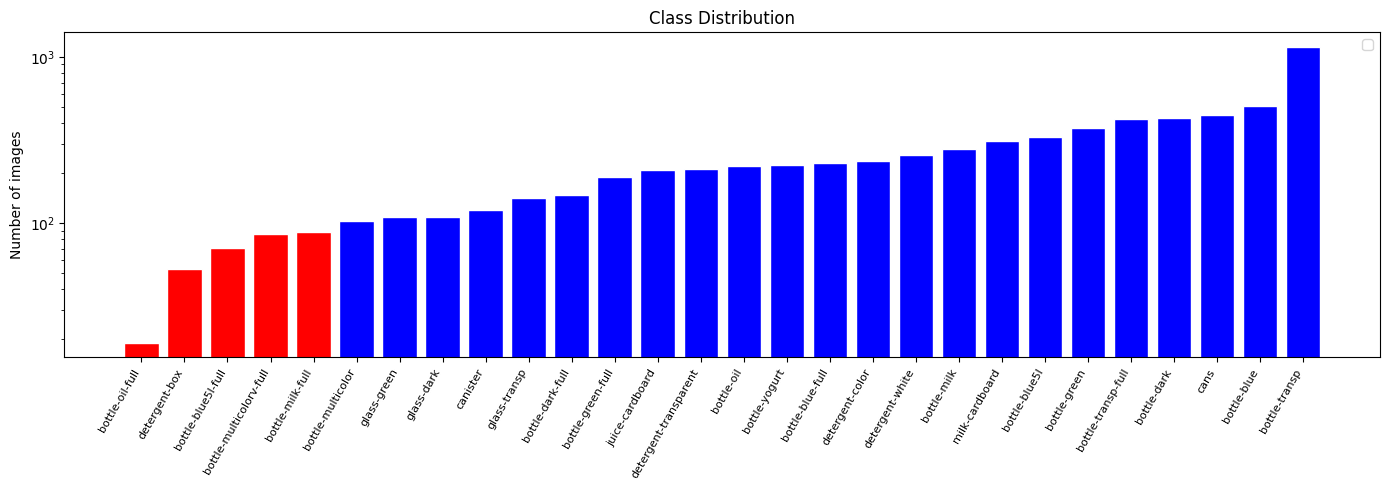

In [ ]:
# Imbalance ratio and minority/majority class stats
class_names_sorted = train_dataset.classes
counts = train_dataset.get_class_counts()

print(f"\nImbalance ratio (max / min): {counts.max() / counts.min():.1f}×")

# Plot Bar chart
order = np.argsort(counts)
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["red" if counts[i] < 100 else "blue" for i in order]
ax.bar(range(len(order)), counts[order], color=colors, edgecolor="white")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([class_names_sorted[i] for i in order], rotation=60, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_ylabel("Number of images")
ax.set_title("Class Distribution")
ax.legend()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


## 7. Build ConvNeXt Model

In [ ]:
def build_convnext(model_name: str, num_classes: int, pretrained: bool = True) -> nn.Module:

    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
    )
    return model

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_convnext(
    CFG["model_name"],
    CFG["num_classes"],
    CFG["pretrained"]
).to(device)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)


## 8. Loss, Optimiser, Scheduler

In [ ]:
# Class-balanced CrossEntropyLoss
# Inverse-frequency weighting means the loss gradient for a sample from
# 'bottle-oil-full' (19 images) is ~60× larger than one from 'bottle-transp'
if CFG["use_class_weights_loss"]:
    samples_per_class  = train_dataset.get_class_counts()
    freq_inverse      = 1.0 / (samples_per_class + 1e-6)
    loss_weights = torch.tensor(freq_inverse / freq_inverse.sum(), dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(
        weight          = loss_weights,
        label_smoothing = CFG["label_smoothing"],
    )

else:
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])


# Split model parameters into two groups based on their names
# backbone is all layers except the final classification head
pretrained_params = [p for n, p in model.named_parameters() if "head" not in n]

# head is only the final classification layer (Linear 768->28 classes)
classifier_params = [p for n, p in model.named_parameters() if "head" in n]

# Create AdamW optimizer with two different learning rates
optimizer = optim.AdamW(
    [
        # backbone gets 10x smaller LR->gentle fine-tuning (already trained on ImageNet)
        {"params": pretrained_params, "lr": CFG["lr"] / 10},

        # head gets full LR->learns fast (randomly initialised, knows nothing)
        {"params": classifier_params, "lr": CFG["lr"]},
    ],
    weight_decay=CFG["weight_decay"],  # L2 regularisation → prevents weights growing too large
)


# Define how learning rate changes each epoch
def get_lr_scale(epoch):
    # LR slowly increases from 0 to full LR
    # prevents unstable updates at the very start of training
    if epoch < CFG["warmup_epochs"]:
        return (epoch + 1) / CFG["warmup_epochs"]


    # LR smoothly decreases from full LR down to min_LR
    # how far through the decay phase are we? (0.0 = start, 1.0 = end)
    decay_progress = (epoch - CFG["warmup_epochs"]) / max(1, CFG["num_epochs"] - CFG["warmup_epochs"])

    # cosine formula- smoothly decays LR following a cosine curve
    return CFG["min_lr"] / CFG["lr"] + 0.5 * (1 - CFG["min_lr"] / CFG["lr"]) * (1 + np.cos(np.pi * decay_progress))


# Attach the get_lr_scale function to the optimizer
# calls get_lr_scale(epoch) after every scheduler.step() to update the LR
scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr_scale)

## 9. Training and Validation Functions

In [ ]:
def mixup_data(x, y, alpha=1.0):
  #Two images are mixed to force the model to learn general features rather than memorising specific images,
  #create synthetic examples for rare classes, and smooth the decision boundaries.
    if alpha > 0:
        blend_ratio = np.random.beta(alpha, alpha)
    else:
        blend_ratio = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    blended_imgs = blend_ratio * x + (1 - blend_ratio) * x[index, :]
    labels_orig, labels_mixed = y, y[index]
    return blended_imgs, labels_orig, labels_mixed, blend_ratio

def mixup_criterion(criterion, pred, labels_orig, labels_mixed, blend_ratio):
  #splits the loss proportionally between both blended labels
  #so the model is penalised fairly for both images rather than being forced to choose just one correct answer.
    return blend_ratio * criterion(pred, labels_orig) + (1 - blend_ratio) * criterion(pred, labels_mixed)

def train_one_epoch(model, loader, optimizer, criterion, device, blend_alpha=0.0):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        if blend_alpha > 0:
            imgs, labels_orig, labels_mixed, blend_ratio = mixup_data(imgs, labels, blend_alpha)
        #remove gradient from the previous batch
        optimizer.zero_grad()
        logits = model(imgs)

        if blend_alpha > 0:
            loss = mixup_criterion(criterion, logits, labels_orig, labels_mixed, blend_ratio)
        else:
            loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        #Update weights
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc="Eval", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        predictions = probs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += imgs.size(0)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

## 10. Training Loop with Early Stopping

In [ ]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

best_accuracy  = 0.0
best_model_weights  = None
early_stop_counter  = 0

BEST_MODEL_PATH = CKPT_FOLDER / f"{CFG['model_name']}_best.pth"

for epoch in range(CFG["num_epochs"]):

    train_loss, train_acc = train_one_epoch(
        model, train_dataloader, optimizer, criterion, device,
        blend_alpha=CFG["blend_alpha"]
    )
    val_loss, val_acc, _, _, _ = evaluate(model, val_dataloader, criterion, device)
    scheduler.step()

    epoch_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(epoch_lr)


    print(
        f"Epoch [{epoch+1:02d}/{CFG['num_epochs']}] "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.3f} | "
        f"LR: {epoch_lr:.2e} "
    )

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save({"epoch": epoch, "model_state": best_model_weights, "val_acc": best_accuracy, "cfg": CFG}, BEST_MODEL_PATH)
        early_stop_counter = 0
        print(f"New best val acc: {best_accuracy:.4f}")
    else:
        early_stop_counter += 1
        if early_stop_counter >= CFG["early_stop_patience"]:
            break

# Restore best weights
model.load_state_dict(best_model_weights)
print(f"\nTraining complete. Final val accuracy: {best_accuracy:.4f}")

Train:   0%|          | 0/221 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [01/20] Train Loss: 2.1924  Acc: 0.163 | Val Loss: 3.4764  Acc: 0.331 | LR: 2.00e-05 
New best val acc: 0.3309


Train:   0%|          | 0/221 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [19/20] Train Loss: 0.9210  Acc: 0.502 | Val Loss: 2.2110  Acc: 0.777 | LR: 3.55e-07 
New best val acc: 0.7768


Train:   0%|          | 0/221 [00:00<?, ?it/s]

Eval:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [20/20] Train Loss: 0.9571  Acc: 0.470 | Val Loss: 2.2066  Acc: 0.779 | LR: 1.00e-07 
New best val acc: 0.7790

Training complete. Final val accuracy: 0.7790


## 11. Plot Training Curves

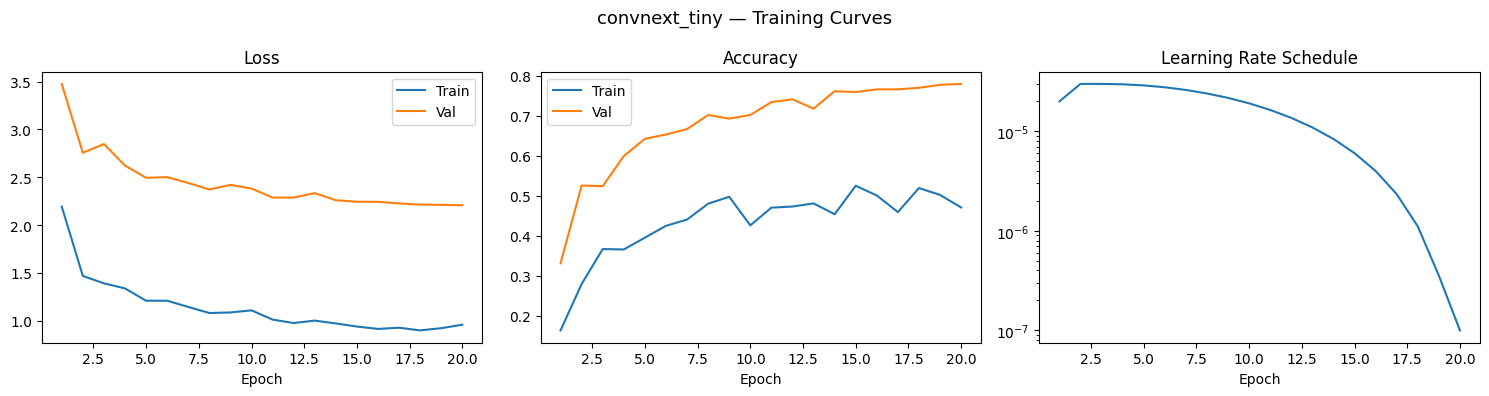

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history["lr"])
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")

plt.suptitle(f"{CFG['model_name']} — Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 12. Evaluation on Test Set

In [ ]:
test_loss, test_acc, preds, labels, probs = evaluate(model, test_dataloader, criterion, device)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# Macro-averaged metrics
precision, recall, f1, support = precision_recall_fscore_support(
    labels, preds, average="macro", zero_division=0
)
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1        : {f1:.4f}")

# Weighted AUC (one-vs-rest)
try:
    auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    print(f"Macro AUC       : {auc:.4f}")
except Exception as e:
    print(f"Could not compute AUC: {e}")

Eval:   0%|          | 0/49 [00:00<?, ?it/s]

Test Loss     : 2.1162
Test Accuracy : 0.7801
Macro Precision : 0.7634
Macro Recall    : 0.8098
Macro F1        : 0.7740
Macro AUC       : 0.9800


## 13. Per-Class Report

In [ ]:
report = classification_report(labels, preds, target_names=class_names_sorted, zero_division=0)
print(report)

                         precision    recall  f1-score   support

            bottle-blue       0.82      0.79      0.80       104
       bottle-blue-full       0.67      0.81      0.74        43
          bottle-blue5l       0.73      0.92      0.81        72
     bottle-blue5l-full       0.80      0.83      0.82        24
            bottle-dark       0.90      0.85      0.88        95
       bottle-dark-full       0.73      0.88      0.80        34
           bottle-green       0.89      0.86      0.88        74
      bottle-green-full       0.76      0.94      0.84        34
            bottle-milk       0.72      0.77      0.75        57
       bottle-milk-full       0.77      0.95      0.85        21
      bottle-multicolor       0.76      0.46      0.58        28
bottle-multicolorv-full       0.66      0.90      0.76        21
             bottle-oil       0.50      0.69      0.58        48
        bottle-oil-full       0.16      0.62      0.26         8
          bottle-transp 

## 14. Confusion Matrix

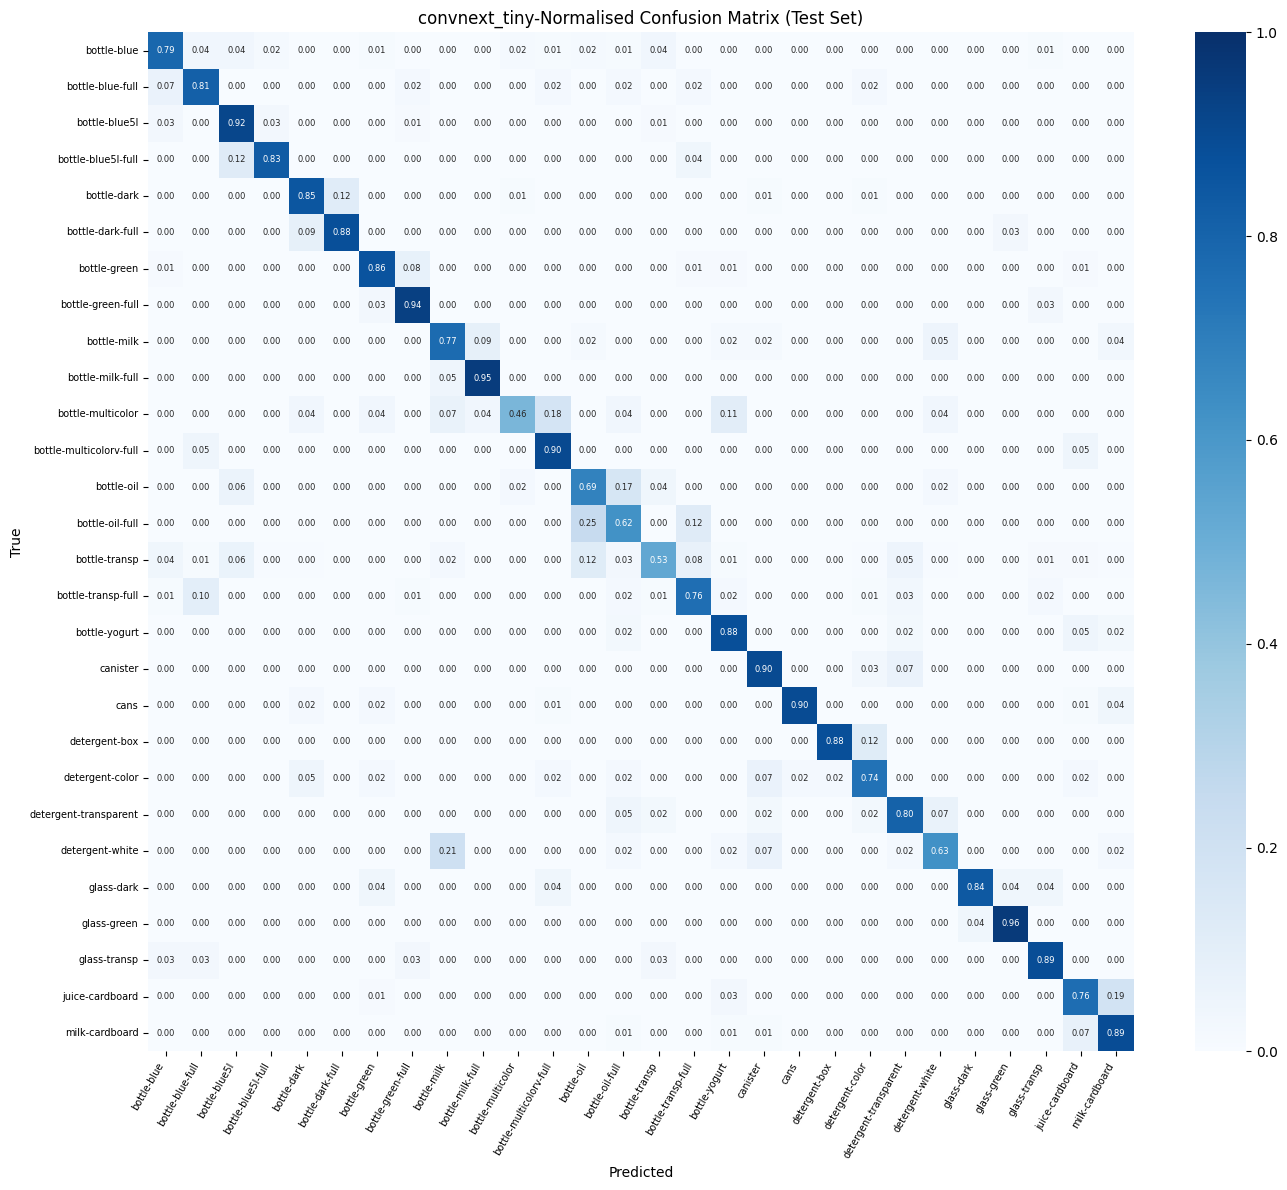

In [ ]:
cm = confusion_matrix(labels, preds)
# Normalise per row
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f",
    xticklabels=class_names_sorted, yticklabels=class_names_sorted,
    cmap="Blues", vmin=0, vmax=1, ax=ax, annot_kws={"size": 6}
)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("True", fontsize=10)
ax.set_title(f"{CFG['model_name']}-Normalised Confusion Matrix (Test Set)", fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 15. Per-Class F1 Bar Chart

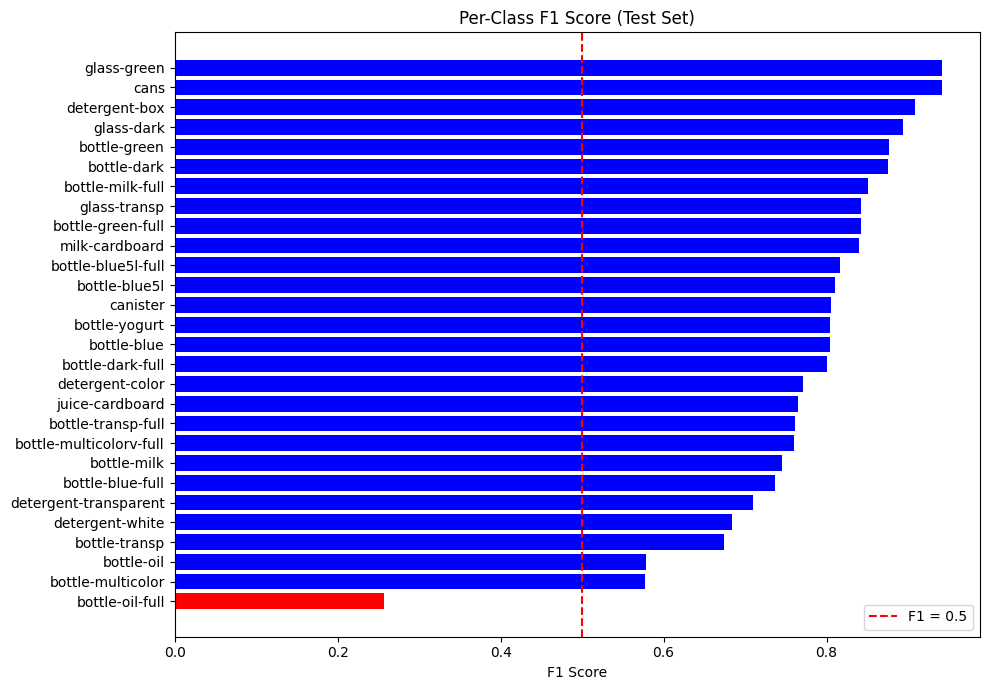

In [ ]:
_, _, per_class_f1, _ = precision_recall_fscore_support(
    labels, preds, average=None, zero_division=0
)

sorted_idx = np.argsort(per_class_f1)
sorted_f1  = per_class_f1[sorted_idx]
sorted_names = [class_names_sorted[i] for i in sorted_idx]

colors = ["red" if f < 0.5 else "blue" for f in sorted_f1]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(sorted_names, sorted_f1, color=colors)
ax.axvline(0.5, color="red", linestyle="--", label="F1 = 0.5")
ax.set_xlabel("F1 Score")
ax.set_title("Per-Class F1 Score (Test Set)")
ax.legend()
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150)
plt.show()

## 16. Post-Training Static Quantization (INT8)

Post-training static quantization (PTQ) converts the FP32 model to INT8 arithmetic
without any retraining.  


In [ ]:
import torch.quantization as tq

import copy, time

# Dynamic Quantization
# Static INT8 quantization is incompatible with ConvNeXt's LayerNorm and
# Dynamic quantization is used instead-it quantizes
# Linear layers to INT8 at inference time without a calibration step.

compressed_model = torch.quantization.quantize_dynamic(
    copy.deepcopy(model).cpu(),   # copy model to CPU
    {torch.nn.Linear},            # only quantize Linear layers
    dtype=torch.qint8             # convert to INT8
)
print("Dynamic quantization complete.")


# Compare model size
def model_size_mb(m, path="/tmp/_modelbase_dataset.pth"):
    torch.save(m.state_dict(), path)
    return os.path.getsize(path) / 1e6

original_size_mb = model_size_mb(model.cpu())
quantized_size_mb = model_size_mb(compressed_model)
model= model.to(device)

# Compare inference latency (CPU, batch=1)
def measure_latency_ms(m, n=100, img_size=224):
    m.eval()
    dummy = torch.randn(1, 3, img_size, img_size)
    for _ in range(10): m(dummy)        # warmup
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n): m(dummy)
    return (time.perf_counter() - t0) / n * 1000

fp32_latency = measure_latency_ms(model.cpu())
int8_latency = measure_latency_ms(compressed_model)
model   = model.to(device)

# Compare accuracy on validation set
@torch.no_grad()
def eval_cpu(m, loader):
    m.eval()
    correct = 0 # Initialize correct
    total = 0
    for imgs, labels in tqdm(loader, desc="Eval CPU", leave=False):
        preds = m(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

fp32_accuracy = eval_cpu(model.cpu(), val_dataloader)
int8_accuracy = eval_cpu(compressed_model,  val_dataloader)
model = model.to(device)

print(f"\nFP32 val accuracy : {fp32_accuracy:.4f}")
print(f"INT8 val accuracy : {int8_accuracy:.4f}")

/tmp/ipykernel_3534/1361485023.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  compressed_model = torch.quantization.quantize_dynamic(


Dynamic quantization complete.


Eval CPU:   0%|          | 0/56 [00:00<?, ?it/s]

Eval CPU:   0%|          | 0/56 [00:00<?, ?it/s]


FP32 val accuracy : 0.7790
INT8 val accuracy : 0.7841


In [ ]:
# Summary bar chart- FP32 vs INT8 (Dynamic)
metrics = {
    "Model size (MB)": [original_size_mb,    quantized_size_mb],
    "Latency (ms)"   : [fp32_latency,      int8_latency],
    "Val accuracy"   : [fp32_accuracy, int8_accuracy],
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, vals) in zip(axes, metrics.items()):
    bars = ax.bar(["FP32", "INT8"], vals, color=["steelblue", "tomato"], width=0.4)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=10)
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle("FP32 vs INT8 Dynamic Quantization", fontsize=13)
plt.tight_layout()
plt.savefig("quantization_comparison.png", dpi=150)
plt.show()

## 20. Save All Outputs

In [ ]:
# Save history for later analysis / report figures
with open(f"{CFG['model_name']}_history.json", "w") as f:
    json.dump(history, f, indent=2)

# Save final model
torch.save({
    "model_state": model.state_dict(),
    "label_map": LABEL_MAP,
    "cfg": CFG,
    "test_acc": float(test_acc),
    "macro_f1": float(f1),
}, f"{CFG['model_name']}_final.pth")

print("All outputs saved.")